In [5]:
'''DATA CLEANING AND WRANGLING'''

'DATA CLEANING AND WRANGLING'

In [6]:
#libraries for data manipulation
import pandas as pd
import numpy as np
import math

#to keep things neat
import warnings
warnings.filterwarnings('ignore')

#for exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns

#for preprocessing and encoding
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder

#for model training and hyperparameter tuning
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

#for saving
import pickle


In [7]:
df=pd.read_csv('car_auction_train.csv')

In [8]:
#creating a diagnostic table to see how we can fix the missing data
diagnostic_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})
diagnostic_df = diagnostic_df.sort_values(by='Missing Values', ascending=False)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(diagnostic_df[diagnostic_df['Missing Values'] > 0])
pd.set_option('display.float_format', lambda x: '%.2f' % x)
display(df.describe())


Dataset Shape: 447048 rows, 12 columns



,Data Type,Missing Values,Missing %
transmission,str,52299,11.698744
color,str,20361,4.554544
interior,str,14155,3.166327
body,str,10593,2.369544
condition,float64,9437,2.110959
trim,str,8570,1.917020
model,str,8372,1.872730
make,str,8287,1.853716
odometer,float64,69,0.015435


,year,condition,odometer,sellingprice
count,447048.00,437611.00,446979.00,447048.00
mean,2010.04,3.42,68353.62,13609.88
std,3.97,0.95,53455.26,9756.83
min,1982.00,1.00,1.00,1.00
25%,2007.00,2.70,28388.50,6900.00
50%,2012.00,3.60,52321.00,12100.00
75%,2013.00,4.20,99139.00,18200.00
max,2015.00,5.00,999999.00,230000.00


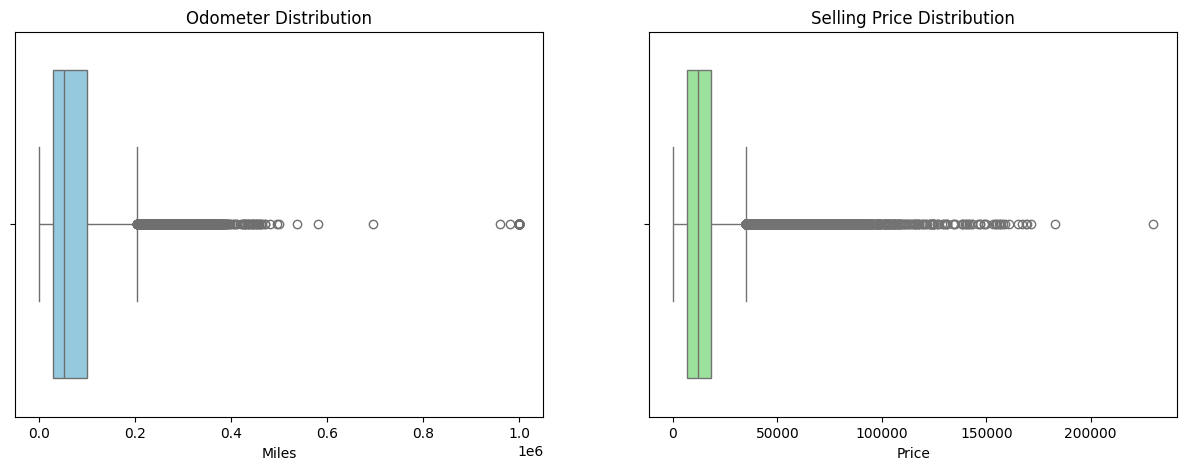

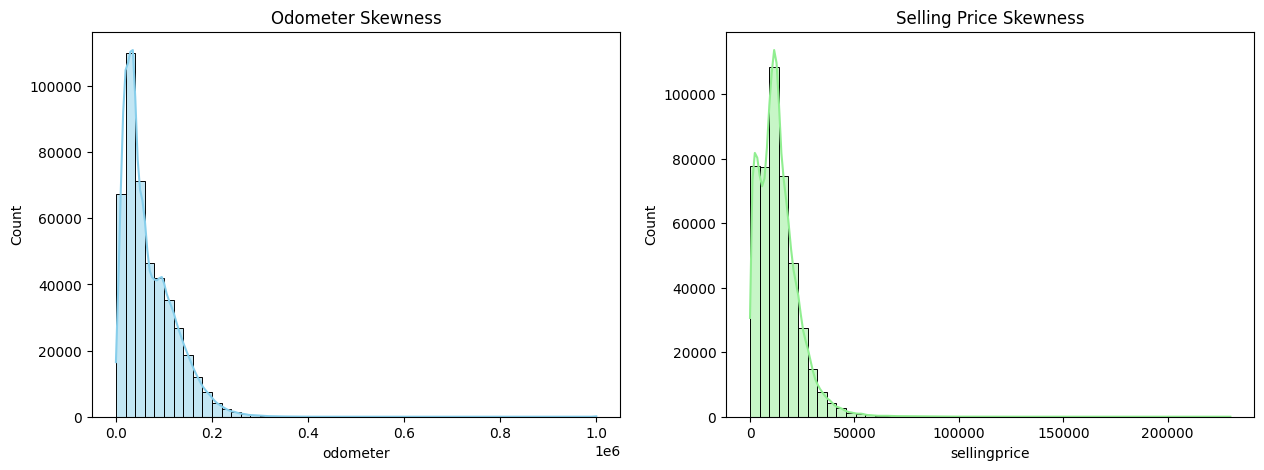

Top 15 Car Makes
make
ford             75367
chevrolet        48373
nissan           43246
toyota           32047
dodge            24764
honda            21872
hyundai          17429
bmw              16710
kia              14477
chrysler         13999
mercedes-benz    13687
jeep             12418
infiniti         12200
volkswagen        9975
lexus             9564
Name: count, dtype: int64

Bottom 15 Car Makes
make
geo             17
aston martin    17
ferrari         15
rolls-royce     13
gmc truck       10
fisker           8
lamborghini      3
daewoo           2
mercedes-b       2
ford truck       2
airstream        1
dot              1
dodge tk         1
hyundai tk       1
chev truck       1
Name: count, dtype: int64

Unique Body Types
body
sedan           193148
suv             114950
hatchback        20952
minivan          20424
coupe            14263
crew cab         13132
wagon            12979
convertible       8351
supercrew         7337
g sedan           5895
supercab        

In [9]:
#now, using charts we will try to find the outliars and what to do with it

#we do this for odometer, and selling price only as outliar is not expected in condition score, and the rest of the data are texts which we are not able to read right now(we will later, using encoding)

#creating a box plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['odometer'], ax=axes[0], color='skyblue')
axes[0].set_title('Odometer Distribution')
axes[0].set_xlabel('Miles')

sns.boxplot(x=df['sellingprice'], ax=axes[1], color='lightgreen')
axes[1].set_title('Selling Price Distribution')
axes[1].set_xlabel('Price')

plt.show()

#creating histogram to figure out the skewness
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['odometer'].dropna(), bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Odometer Skewness')

sns.histplot(df['sellingprice'].dropna(), bins=50, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Selling Price Skewness')

plt.show()

#now to check for typos
print("Top 15 Car Makes")
print(df['make'].str.lower().value_counts().head(15))

print("\nBottom 15 Car Makes")
print(df['make'].str.lower().value_counts().tail(15))

# Check the 'body' column for overlapping categories (like 'Sedan' vs 'sedan')
print("\nUnique Body Types")
print(df['body'].str.lower().value_counts().head(20))

In [10]:
#Data cleaning to fix missing values, outliers, and typos

'''Fixing typos first'''
df['make'] = df['make'].str.lower().str.strip()
df['body'] = df['body'].str.lower().str.strip() #we removed the spaces and changed the word to lowercase

#now we fix the typos manually
df['make'] = df['make'].str.replace(r'\s+truck|\s+tk', '', regex=True)
df.loc[df['make'] == 'mercedes-b', 'make'] = 'mercedes-benz'
df.loc[df['make'] == 'vw', 'make'] = 'volkswagen'
df.loc[df['make'] == 'chev', 'make'] = 'chevrolet' 
df.loc[df['make'] == 'chevy', 'make'] = 'chevrolet'  
df.loc[df['make'] == 'dot', 'make'] = 'dodge'

#we are also cleaning the body column. We aggressively cleaned the body column because it is a Low-Cardinality feature(we did not clean model and trim because of high cardinality. we will encode them later)
truck_cabs = 'crew cab|supercrew|supercab|regular cab|extended cab|quad cab|double cab|crewmax cab|king cab'
df.loc[df['body'].str.contains(truck_cabs, na=False, regex=True), 'body'] = 'pickup' #it replaces all the values which are truck_cab and change it to 'pickup'

df.loc[df['body'].str.contains('g sedan', na=False), 'body'] = 'sedan'
df.loc[df['body'].str.contains('g coupe', na=False), 'body'] = 'coupe'


'''removing extreme outliars'''
price_low = df['sellingprice'].quantile(0.01)
price_high = df['sellingprice'].quantile(0.99)
odom_high = df['odometer'].quantile(0.99)

df = df[(df['sellingprice'] >= price_low) & (df['sellingprice'] <= price_high)]
df = df[(df['odometer'] <= odom_high) | (df['odometer'].isna())]  #We use | with isna() so we don't accidentally drop rows with missing odometers yet


'''filling missing values(imputation)
Reason: If you build a model that expects perfectly clean data by dropping all rows with missing values during training, your model will instantly break in the Arena. If the simulation hands your agent a dictionary for a Honda Civic and the condition value happens to be null. Also there will be massive data loss for columns like transmission. By imputing missing text values with the word 'unknown' (like we did for transmission and body), we are actually creating a brand new category. XGBoost is smart enough to recognize patterns in why data is missing.
'''

text_columns = ['transmission', 'body', 'color', 'interior', 'make', 'model', 'trim']
df[text_columns] = df[text_columns].fillna('unknown')
#Fill Numerical columns with the median (calculated AFTER outliers were removed)[we did not use mean because the mean is incredibly sensitive to a skewed distribution. Even though we chopped off the impossible 99th percentile outliers, the odometer data is still right-skewed.][we did not use mode because this works great for categories (like colors or car brands), but it is terrible for continuous numbers like like odometer. even though we may use it for condition, it is still preferred to use median because its more safe]
median_condition = df['condition'].median()
df['condition'] = df['condition'].fillna(median_condition)
median_odometer = df['odometer'].median()
df['odometer'] = df['odometer'].fillna(median_odometer)

# Final Sanity Check to prove 0 missing values
print("Data Cleaning Complete")
print(f"New Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Remaining Missing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Data Cleaning Complete
New Dataset Shape: 434510 rows, 12 columns
Remaining Missing Values:
Series([], dtype: int64)


In [11]:
'''EDA'''

'EDA'

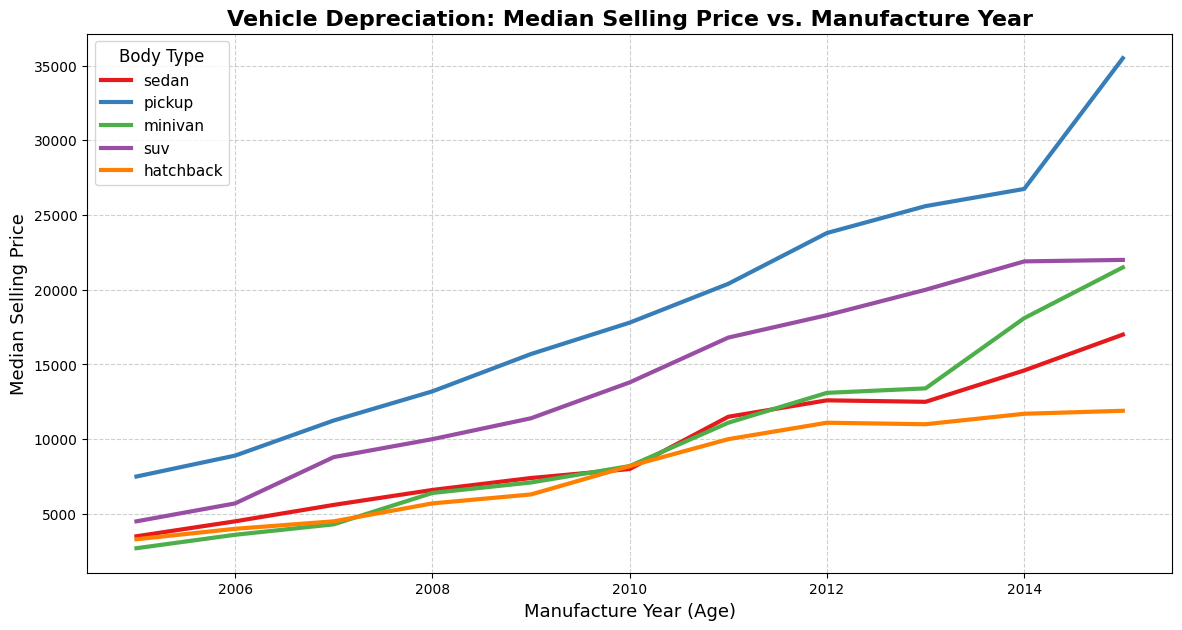

In [12]:
#DEPRECIATION ACROSS THE BODY TYPES(It tells how does time affect the base value of different vehicle shapes)
#time is the biggest driver of value loss, but prove utility vehicles (like pickups) resist this decay better than luxury sedans


top_bodies = df['body'].value_counts().head(5).index.tolist() #we do this for top 5 most common body types
depreciation_df = df[(df['body'].isin(top_bodies)) & (df['year'] >= 2005)] # Because cars older than 20 years stop depreciating and start becoming "Classic Cars," which makes their prices go back up and ruins the depreciation curve
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=depreciation_df, 
    x='year', 
    y='sellingprice', 
    hue='body',          #Color the lines by body type
    estimator='median',  #We use median again to protect against high-end luxury skew
    errorbar=None,      
    linewidth=3,
    palette='Set1'       #Uses a sharp, high-contrast color palette
)
plt.title('Vehicle Depreciation: Median Selling Price vs. Manufacture Year', fontsize=16, fontweight='bold')
plt.xlabel('Manufacture Year (Age)', fontsize=13)
plt.ylabel('Median Selling Price', fontsize=13)
plt.legend(title='Body Type', fontsize=11, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

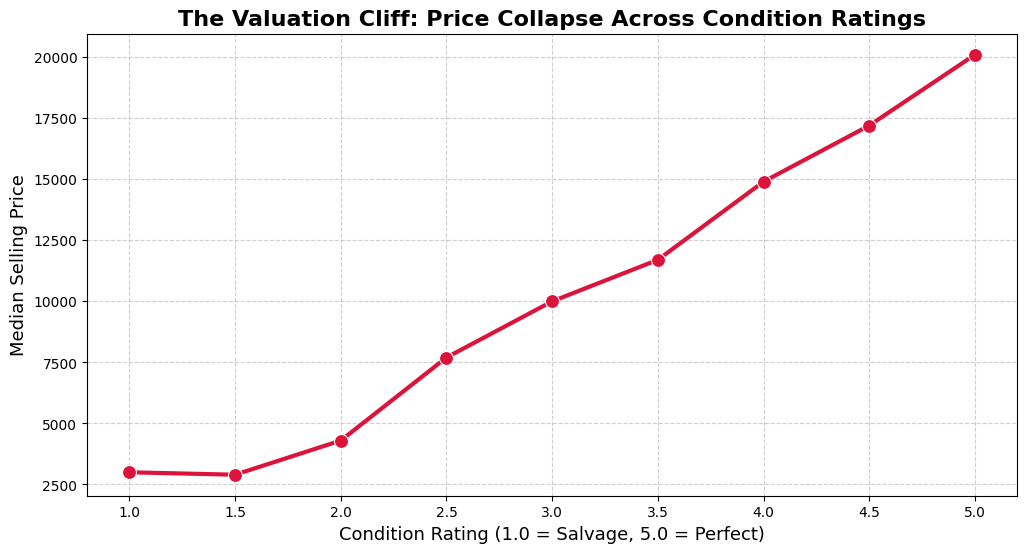

The Rate of Change (0.5 Resolution)
             sellingprice  dollar_loss  percentage_loss (%)
cond_bucket                                                
5.00             20100.00          NaN                  NaN
4.50             17200.00      2900.00                14.43
4.00             14900.00      2300.00                13.37
3.50             11700.00      3200.00                21.48
3.00             10000.00      1700.00                14.53
2.50              7700.00      2300.00                23.00
2.00              4300.00      3400.00                44.16
1.50              2900.00      1400.00                32.56
1.00              3000.00       100.00                 3.45


In [ ]:
#THE CONDITION RATING THRESHOLD(we find where price collapses non-linearly)

df['condition_rounded'] = (df['condition'] * 2).round() / 2  #this creates distinct groups like 2.0, 2.5 instead of 3.1415
#If we do this without rounding, we will run into the "Signal vs. Noise" problem. The condition column has highly granular decimal scores anyways
condition_df = df[(df['condition_rounded'] >= 1.0) & (df['condition_rounded'] <= 5.0)] #we  remove the condition number outside this range as these are just outliers or errors
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=condition_df,
    x='condition_rounded',
    y='sellingprice',
    estimator='median',
    errorbar=None,
    linewidth=3,
    color='crimson',
    marker='o',    
    markersize=10
)

plt.title('The Valuation Cliff: Price Collapse Across Condition Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Condition Rating (1.0 = Salvage, 5.0 = Perfect)', fontsize=13)
plt.ylabel('Median Selling Price', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
df.drop('condition_rounded', axis=1, inplace=True) #Clean up the temporary column so it doesn't mess with our ML model later


#To find the point on non-linearity, we calculate the First Derivative of the data. We will calculate the exact percentage of value a car loses for every single point its condition drops as seeing from eyes, the graph seems pretty linear, but, lets not trust our eyes, but the data
df['cond_bucket'] = (df['condition'] * 2).round() / 2
cliff_check = df.groupby('cond_bucket')['sellingprice'].median().sort_index(ascending=False).to_frame()
cliff_check['dollar_loss'] = cliff_check['sellingprice'].diff().abs()
cliff_check['percentage_loss (%)'] = (cliff_check['sellingprice'].pct_change().abs() * 100).round(2)
print("The Rate of Change (0.5 Resolution)")
print(cliff_check)
df.drop('cond_bucket', axis=1, inplace=True)

#from this we conclude that at a severe collapse occurs at 2.5 mark with vehicle loosing upto 40% of their value when dropping to a rating of 2.0, so it should be the point where non-linearity occurs and beyond which the machine should be careful to purchase the car in the auction

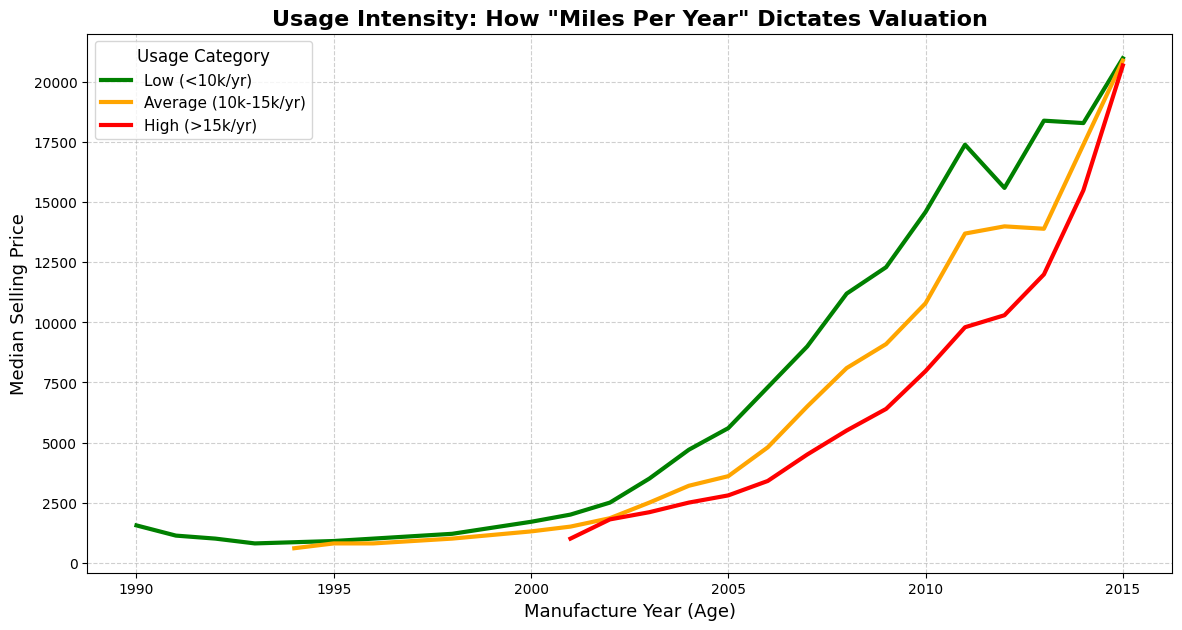

In [14]:
#USAGE INTENSITY

#We use 2015 as the baseline since it's the max year in the dataset.
df['car_age'] = 2015 - df['year'] + 1 #We add +1 so brand new 2015 cars have an age of 1 (preventing division by zero errors)
df['miles_per_year'] = df['odometer'] / df['car_age'] #we engineered a new feature, so it is feature engineering
df['usage_intensity'] = 'Average (10k-15k/yr)' 
df.loc[df['miles_per_year'] < 10000, 'usage_intensity'] = 'Low (<10k/yr)'
df.loc[df['miles_per_year'] > 15000, 'usage_intensity'] = 'High (>15k/yr)'
usage_df = df[df['year'] >= 1990]
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=usage_df,
    x='year',
    y='sellingprice',
    hue='usage_intensity',
    hue_order=['Low (<10k/yr)', 'Average (10k-15k/yr)', 'High (>15k/yr)'],
    estimator='median',
    errorbar=None,
    linewidth=3,
    palette=['green', 'orange', 'red'] # Green for Low, Orange for Avg, Red for High
)
plt.title('Usage Intensity: How "Miles Per Year" Dictates Valuation', fontsize=16, fontweight='bold')
plt.xlabel('Manufacture Year (Age)', fontsize=13)
plt.ylabel('Median Selling Price', fontsize=13)
plt.legend(title='Usage Category', fontsize=11, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

df.drop(['car_age', 'miles_per_year', 'usage_intensity'], axis=1, inplace=True)

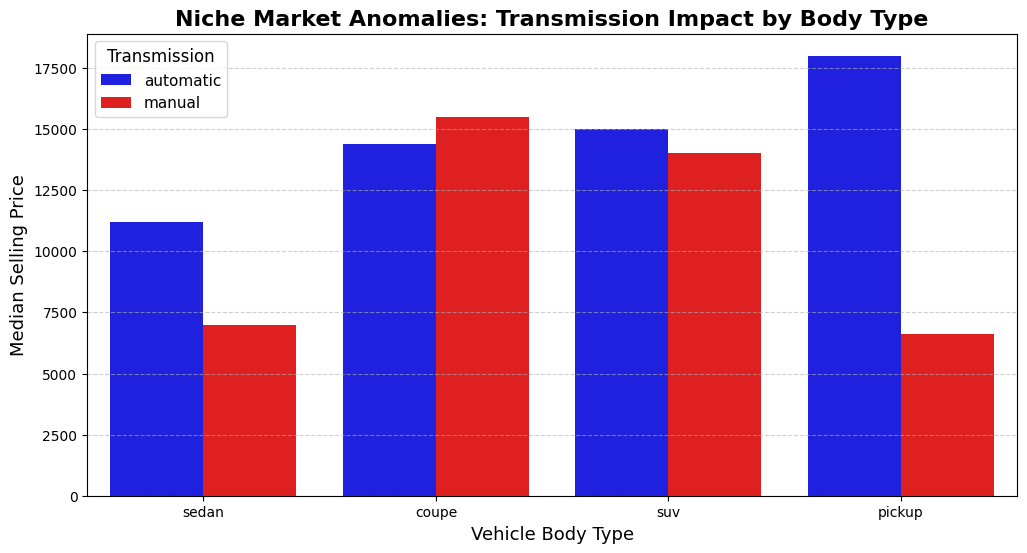

In [15]:
#TRANSMISSION X BODY TYPE
#the strategy is: Does a manual transmission ruin the value of a practical Sedan? Yes. But does it ruin the value of a sporty Coupe?(when we look at the transmission column by itself, automatic cars almost always sell for more money)
#Note: We are going to temporarily filter out our 'unknown' transmissions for this chart, so we get a clean comparison of just Automatic vs Manual
target_bodies = ['sedan', 'coupe', 'suv', 'pickup'] #we choose the big four, so the that the data is as close to the true value
interaction_df = df[(df['transmission'].isin(['automatic', 'manual'])) & (df['body'].isin(target_bodies))]
plt.figure(figsize=(12, 6))
sns.barplot(
    data=interaction_df,
    x='body',
    y='sellingprice',
    hue='transmission',
    estimator='median',
    errorbar=None,
    palette=['blue', 'red'] # Blue for Automatic, Red for Manual
)
plt.title('Niche Market Anomalies: Transmission Impact by Body Type', fontsize=16, fontweight='bold')
plt.xlabel('Vehicle Body Type', fontsize=13)
plt.ylabel('Median Selling Price', fontsize=13)
plt.legend(title='Transmission', fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [16]:
'''TARGET ENCODING AND DATA PIPELINE'''

'TARGET ENCODING AND DATA PIPELINE'

In [ ]:
#we do train/test split, target encoding, prevent data leakage and make a separate file for encoders called as 'encoders_TakuTajoJuly.pkl'
X = df.drop('sellingprice', axis=1) #separating the feature X from the target variable y
y = df['sellingprice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #split before encoding to prevent data leakage
categorical_cols = ['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior'] #target encoding
saved_encoders = {}
for col in categorical_cols:
    target_mapper = y_train.groupby(X_train[col]).median()
    saved_encoders[col] = target_mapper
    X_train[col] = X_train[col].map(target_mapper)
    X_test[col] = X_test[col].map(target_mapper)
    global_median = y_train.median() #Calculate the median price of all the cars in the training set (global_median). If any car in the test set just got turned into a missing value because we didn't recognize its text, we fill that missing value with this safe global median.
    X_test[col] = X_test[col].fillna(global_median)

with open('encoders_TakuTajoJuly.pkl', 'wb') as f:
    pickle.dump(saved_encoders, f)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print("Successfully saved 'encoders_TakuTajoJuly.pkl' to your directory.")

Training Features Shape: (347608, 11)
Testing Features Shape: (86902, 11)
Successfully saved 'encoders_TakuTajoJuly.pkl' to your directory.


In [18]:
'''MODEL TRAINING AND EVALUATION'''

'MODEL TRAINING AND EVALUATION'

In [ ]:
#Model choice justification: An XGBoost Regressor was selected over linear models due to its tree-based architecture, which natively handles the non-linear depreciation patterns discovered during EDA (such as the sharp valuation collapse at the 3.0 condition rating)
#We use logarithmic transformation to sellingprice as from EDA we have seen that the graph is right skewed
#Validation Strategy & Tuning Method: Given the large volume of the dataset (about 400,000 rows), an exhaustive GridSearchCV is computationally prohibitive. Therefore, RandomizedSearchCV was employed with 3-Fold Cross-Validation.

if 'state' in X_train.columns:
    X_train = X_train.drop('state', axis=1)
    X_test = X_test.drop('state', axis=1)

text_cols = X_train.select_dtypes(include=['object', 'string']).columns
if len(text_cols) > 0:
    print(f"Dropping remaining text columns: {list(text_cols)}")
    X_train = X_train.drop(text_cols, axis=1)
    X_test = X_test.drop(text_cols, axis=1)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

#training default model
default_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
default_model.fit(X_train, y_train_log)
default_preds_log = default_model.predict(X_test) #predicting
default_preds = np.expm1(default_preds_log) #taking antilog

default_mae = mean_absolute_error(y_test, default_preds)
default_rmse = np.sqrt(mean_squared_error(y_test, default_preds))


#hyperparameter tuning
param_grid = {
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

#Initialize Randomized Search (3-Fold CV to save time on large data)
tuned_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=tuned_xgb,
    param_distributions=param_grid,
    n_iter=10,           # Tries 10 random combinations from the grid
    scoring='neg_mean_absolute_error', 
    cv=3,                # 3-Fold Cross Validation
    verbose=1,
    random_state=42,
    n_jobs=-1            
)
random_search.fit(X_train, y_train_log)
best_model = random_search.best_estimator_
tuned_preds_log = best_model.predict(X_test)
tuned_preds = np.expm1(tuned_preds_log)

tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))

#Final comparison report
print("FINAL RUBRIC COMPARISON: Default vs. Tuned")
print(f"Best Hyperparameters Found: {random_search.best_params_}\n")
print("DEFAULT MODEL (Log-Transformed):")
print(f"MAE:  ${default_mae:,.2f}")
print(f"RMSE: ${default_rmse:,.2f}\n")
print("TUNED MODEL (Log-Transformed):")
print(f"MAE:  ${tuned_mae:,.2f}")
print(f"RMSE: ${tuned_rmse:,.2f}")

#saving the model
with open('model_TakuTajoJuly.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Model successfully saved as 'model_TakuTajoJuly.pkl'.")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
FINAL RUBRIC COMPARISON: Default vs. Tuned
Best Hyperparameters Found: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

DEFAULT MODEL (Log-Transformed):
MAE:  $1,427.33
RMSE: $2,180.15

TUNED MODEL (Log-Transformed):
MAE:  $1,227.35
RMSE: $1,893.74
Model successfully saved as 'model_TakuTajoJuly.pkl'.


In [23]:
%%writefile agent_TakuTajoJuly.py
'''AGENT'''

class LiveAuctionAgent:
    def __init__(self):
        self.bankroll = 500000.0
        self.predicted_value = 0.0

        self.current_round = 1

        base_path = os.path.dirname(os.path.abspath(__file__))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with open(os.path.join(base_path, "model_TakuTajoJuly.pkl"), "rb") as f:
                self.model = pickle.load(f)
            with open(os.path.join(base_path, "encoders_TakuTajoJuly.pkl"), "rb") as f:
                self.encoders = pickle.load(f)

    
    def analyze_item(self, item_features: dict):
        feature_cols = ['year', 'make', 'model', 'trim', 'body', 'transmission', 
                        'condition', 'odometer', 'color', 'interior']
        features = []
        for col in feature_cols:
            val = item_features.get(col, None)

            if col in ['year', 'condition', 'odometer']:
                #for numeric columns
                features.append(float(val) if val is not None else 0.0)
            else:
                # Categorical columns (Applying our Target Encoding)
                target_mapper = self.encoders[col]

                if val in target_mapper:
                    features.append(float(target_mapper[val]))
                else:
                    features.append(float(target_mapper.median()))

        input_data = np.array([features])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            log_prediction = self.model.predict(input_data)[0]
            self.predicted_value = float(np.expm1(log_prediction))
        
        self.current_round = 1

        
    def place_bid(self, current_highest_bid: float) -> float:
        """Deterministic Bid Sequence: The Asymptotic Gap Strategy"""
        target_margin = 0.85 
        max_willing_to_pay = min(self.predicted_value * target_margin, self.bankroll) #we have a 15% profit margin

        gap = max_willing_to_pay - current_highest_bid
        if gap <= 0:
            return 0.0  # Fold. we drop out if the price exceeds our profit margin or bankroll

        round_weight = min(0.5, self.current_round * 0.10)

        bid_increment = gap * round_weight
        next_bid = current_highest_bid + bid_increment

        self.current_round += 1 #Increment the round tracker in case someone outbids us and we have to bid again

        return round(next_bid, 2)

    
    def auction_result(self, won: bool, winning_bid: float, actual_price: float, current_bankroll: float):
        """Updates the bankroll at the end of the car's auction."""
        self.bankroll = current_bankroll
        self.current_round = 1        

Overwriting agent_TakuTajoJuly.py
